# Лабораторная работа 5. Кепстр, оценка основного тона (ОТ) периодических импульсных сигналов с использованием кепстра

**Цель работы**: исследование свойств кепстра и кепстрограммы, ее применение для оценки ОТ периодических импульсных сигналов и речевых сигналов.

 <hr>        

<font style="color:#1560BD;" size="5">[Начальные установки](#introduction)</font>

<font style="color:#1560BD;" size="5">[Задание 1. Исследование белого и розового шума](#job1)</font>    

<font style="color:#1560BD;" size="5">[Задание 2. Исследование периодического импульсного сигнала](#job2)</font>    

<font style="color:#1560BD;" size="5">[Задание 3. Тональная структура гласных РС мужчины и женщины](#job3)</font>    

<font style="color:#1560BD;" size="5">[Задание 4. ](#job4)</font>    

<font style="color:#1560BD;" size="5">[Задание 5. Исследование тональной структуры и определение частоты ОТ сигналов](#job5)</font>    

<font style="color:#1560BD;" size="5">[Задание 6. Исследование периодической структуры сигнала](#job6)</font>  

### Начальные установки
<a id="introduction"></a>

In [ ]:
# Импорт необходимых библиотек
import matplotlib.pyplot as plt
import librosa
import numpy as np
from scipy.fft import fft, ifft
from scipy.signal import hilbert

# Игнорируем предупреждения
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
# Проверка версии библиотеки
print(librosa.__version__)

0.11.0


In [ ]:
# Конфигурируем директорию данных
Speech_dir = "/home/artyom/myprojects/ITMO/AEA/mors/speech"  # Речевые треки для текущей лабораторной работы

# Основные частоты дискретизации
sr11025 = 11025
sr16000 = 16000

<div class="alert alert-block alert-info">
<b>Задание 1. Исследование белого и розового шума</b> 
<a id="job1"></a>

* Возьмите сигнал белого шума **16white_noise.wav**. Постройте кепстрограмму и далее вычислите средний кепстр.
* Уменьшите амплитуду сигнала в $е$ раз(2.73) и постройте средний кепстр. Как изменился кепстр? Объясните.
* Возьмите сигнал розового шума **16pink_noise.wav**. Постройте средний кепстр. В чем состоит качественное отличие среднего кепстра розового и белого шума?
</div>

In [ ]:
# Вычисление мгновенного кепстра
def compute_instant_cepstrum(x):
    """
    Вычисление мгновенного кепстра
    x: фрейм сигнала
    """
    spectrum = fft(np.hamming(len(x)) * x)
    power_spectrum = np.abs(spectrum) ** 2

    log_spectrum = np.log(power_spectrum + 1e-10)
    cepstrum = np.real(ifft(log_spectrum))

    return cepstrum[: len(x) // 2]

In [ ]:
# Вычисление среднего кепстра medium
def compute_medium_cepstrum(X, fft_size, hop_size):
    """
    Вычисление среднего кепстра medium
    X: сигнал
    fft_size: длина кадра (в отсчетах)
    hop_size: сдвиг (в отсчетах)
    """
    medium_cepstrum = np.zeros(fft_size // 2)

    frames = librosa.util.frame(X, frame_length=fft_size, hop_length=hop_size)
    frames = frames.T

    window = np.hamming(fft_size)
    frames_windowed = frames * window

    for frame in frames_windowed:
        medium_cepstrum += compute_instant_cepstrum(frame)

    return medium_cepstrum / len(frames)

In [ ]:
# Вычисление кепстрограммы
def compute_cepstralgram(X, Fd, fft_size=1024, hop_length=512, n_ceps=40):
    """
    Вычисление кепстрограммы
    X: сигнал
    Fd: частота дискретизации
    fft_size: размер FFT
    hop_length: сдвиг
    n_ceps: количество кепстральных коэффициентов (нулевой коэффициент не используется)
    """
    Cepstralgram = []
    frames = librosa.util.frame(X, frame_length=fft_size, hop_length=hop_length)
    frames = frames.T

    window = np.hamming(fft_size)
    frames_windowed = frames * window

    for frame in frames_windowed:
        cepstrum = compute_instant_cepstrum(frame)
        Cepstralgram.append(cepstrum[1:n_ceps])

    Cepstralgram = np.array(Cepstralgram).T

    # Оси
    time_axis = np.arange(Cepstralgram.shape[1]) * hop_length / Fd
    quef_axis = np.arange(n_ceps) * (fft_size / 2) / Fd

    return Cepstralgram, time_axis, quef_axis

In [ ]:
def compute_quefrency_vector(Fd, frame_size):
    """
    Вычисление quefrency шкалы для кепстра (в мс)
    Fd: частота дискретизации
    fft_size: размер FFT
    """
    return np.linspace(0, 1000 * frame_size / Fd, frame_size // 2)

In [ ]:
# Построение и визуализация кепстрограммы
def visual_cepstrogram(X, Fd, n_fft, hop_length, str_title):
    Cepstralgram, time_axis, quef_axis = compute_cepstralgram(X, Fd, n_fft, hop_length)

    quefrency_vector = compute_quefrency_vector(Fd, n_fft)

    plt.figure(figsize=(12, 6))
    plt.imshow(
        Cepstralgram,
        aspect="auto",
        origin="lower",
        extent=[time_axis[0], time_axis[-1], quefrency_vector[0], quefrency_vector[-1]],
        cmap="viridis",
    )
    plt.xlabel("Время, с")
    plt.ylabel("Quefrency, мс")
    plt.title(str_title)
    plt.colorbar(label="Амплитуда")
    plt.tight_layout()
    plt.show()

In [ ]:
# Построение и визуализация среднего амплитудного спектра
def visual_mean_spectrum(X, Fd, n_fft, f_max, str_title):
    S = np.abs(librosa.stft(X, n_fft=n_fft, hop_length=n_fft // 2))
    S_AVG = np.mean(S, axis=1)

    # Частоты
    freqs = librosa.fft_frequencies(sr=Fd, n_fft=n_fft)

    plt.figure(figsize=(14, 5))
    plt.title(str_title)
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")

    plt.plot(freqs, S_AVG)
    if f_max > 0:
        plt.xlim(0, f_max)
    plt.grid(True)
    plt.show()

In [ ]:
# Загружаем сигнал 16white_noise.wav (с частотой 16000)
data_16white_noise, sr_16white_noise = librosa.load(
    Speech_dir + "//16white_noise.wav", sr=sr16000
)

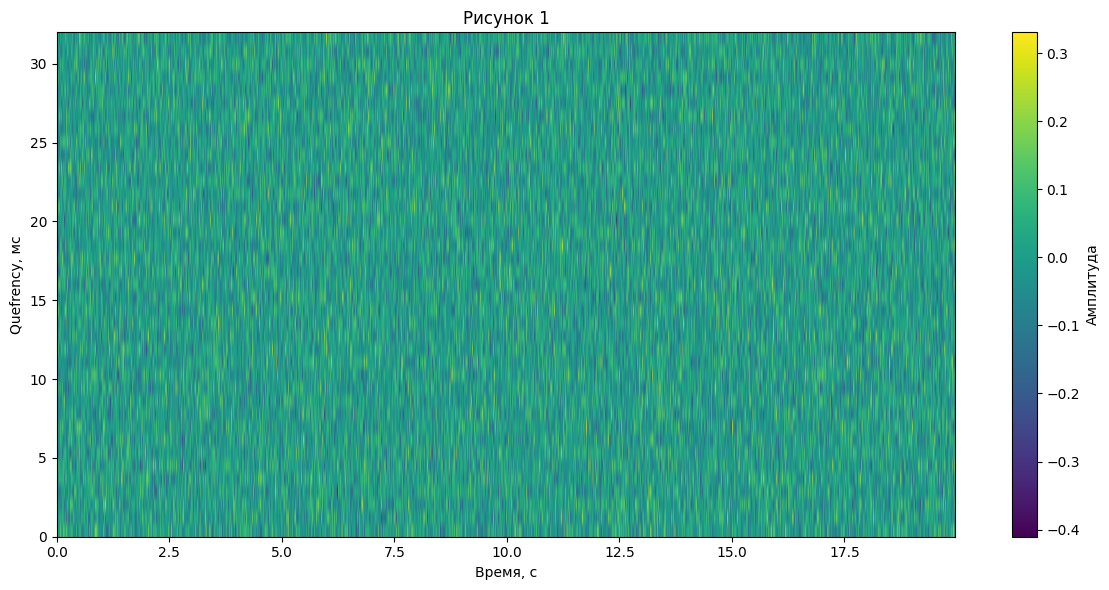

In [ ]:
# Строим и визуализируем кепстрограмму
fft_size = 512
visual_cepstrogram(
    data_16white_noise, sr_16white_noise, fft_size, fft_size // 2, "Рисунок 1"
)

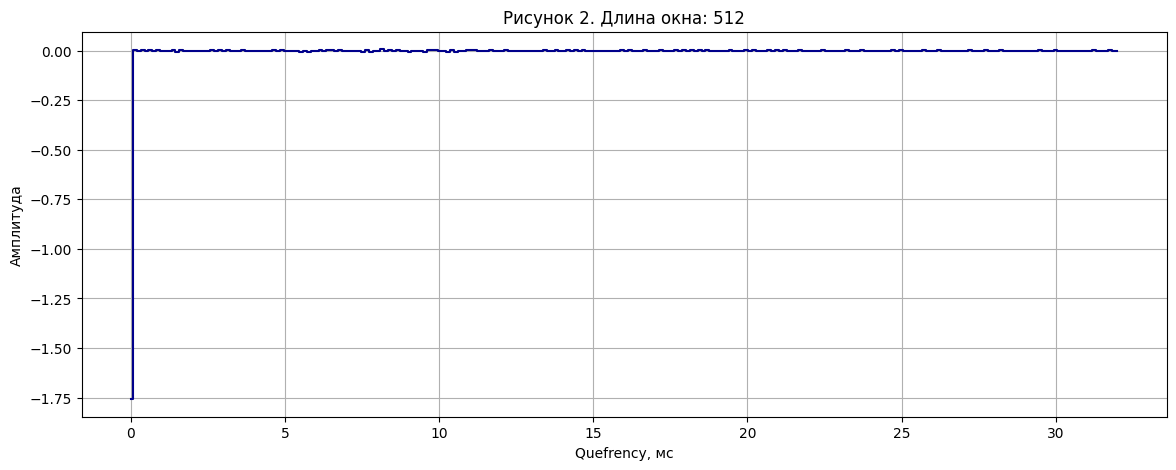

In [ ]:
# Строим и визуализируем средний кепстр
frame_size = 512

medium_cepstrum = compute_medium_cepstrum(
    data_16white_noise, frame_size, frame_size // 2
)
quefrency_vector = compute_quefrency_vector(sr_16white_noise, frame_size)

plt.figure(figsize=(14, 5))
plt.step(quefrency_vector, medium_cepstrum, color="darkblue", where="mid")
plt.grid(True)
plt.title("Рисунок 2. Длина окна: {:d}".format(frame_size))
plt.xlabel("Quefrency, мc")
plt.ylabel("Амплитуда")
plt.show()

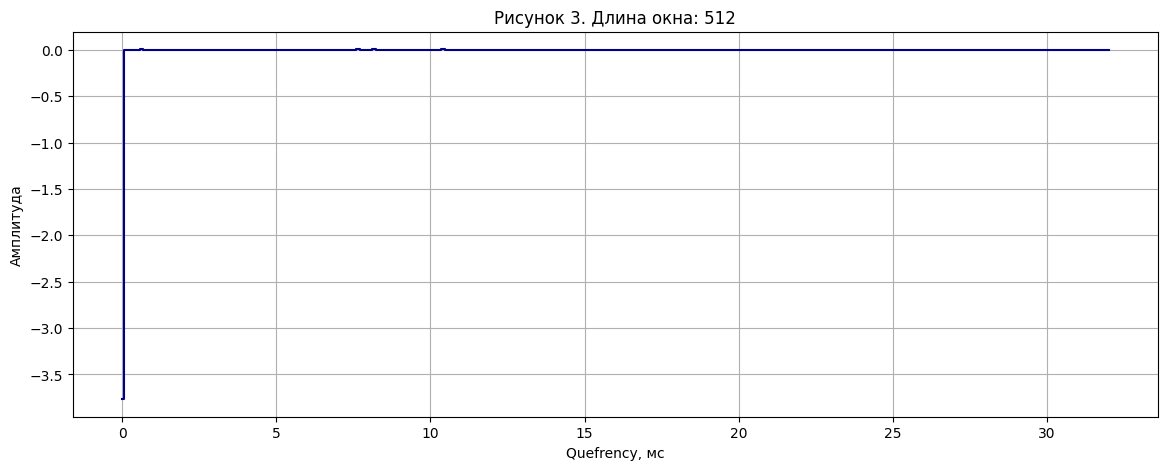

In [ ]:
# Уменьшаем амплитуду сигнала в e раз и строим средний кепстр
medium_cepstrum = compute_medium_cepstrum(
    data_16white_noise / 2.73, frame_size, frame_size // 2
)

plt.figure(figsize=(14, 5))
plt.step(quefrency_vector, medium_cepstrum, color="darkblue", where="mid")
plt.grid(True)
plt.title("Рисунок 3. Длина окна: {:d}".format(frame_size))
plt.xlabel("Quefrency, мc")
plt.ylabel("Амплитуда")
plt.show()

In [ ]:
# Загружаем сигнал 16pink_noise.wav (с частотой 16000)
data_16pink_noise, sr_16pink_noise = librosa.load(
    Speech_dir + "//16pink_noise.wav", sr=sr16000
)

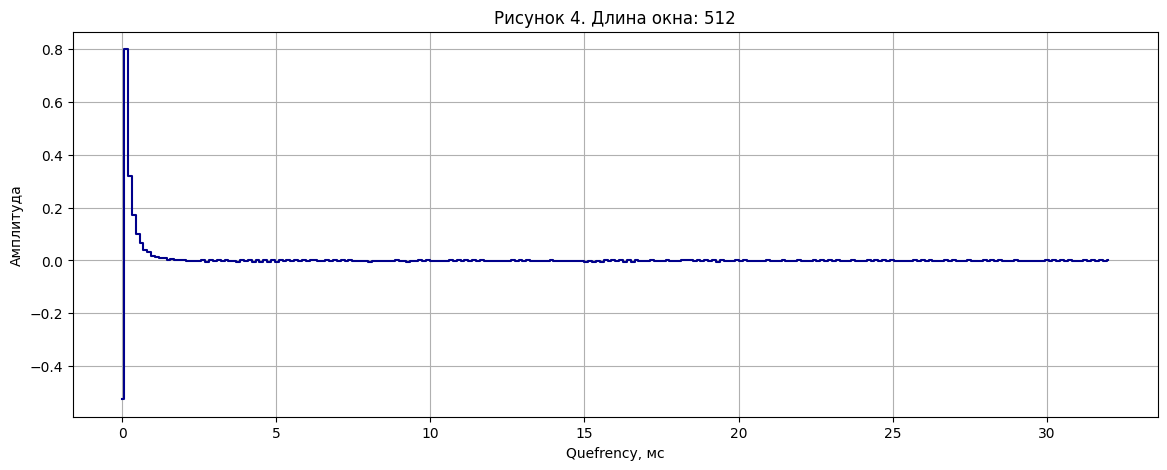

In [ ]:
# Строим и визуализируем средний кепстр
frame_size = 512

medium_cepstrum = compute_medium_cepstrum(
    data_16pink_noise, frame_size, frame_size // 2
)
quefrency_vector = compute_quefrency_vector(sr_16pink_noise, frame_size)

plt.figure(figsize=(14, 5))
plt.step(quefrency_vector, medium_cepstrum, color="darkblue", where="mid")
plt.grid(True)
plt.title("Рисунок 4. Длина окна: {:d}".format(frame_size))
plt.xlabel("Quefrency, мc")
plt.ylabel("Амплитуда")
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 1:</b>
<a id="answer-job1"></a>

* Уменьшите амплитуду сигнала в $е$ раз(2.73) и постройте средний кепстр. Как изменился кепстр?

Значение амплитуды в момент времени 0 окажется меньше почти в два раза.
Поскольку кепстр вычисляется как натуральный логарифм мощности, то при деление мы получаем разность двух логарифмов: квадрата амлитуды и квадрата e.
Натуральный логарифм от экспоненты в квадрате будет равен 2, поэтому и значение на графике ниже на 2.

* Возьмите сигнал розового шума **16pink_noise.wav**. Постройте средний кепстр. В чем состоит качественное отличие среднего кепстра розового и белого шума?

Кепстр у розового шума выглядит как убывающая функция.
Это связано с тем, что спектральаня огибающая у белого шума плоская, в отличие от розового.

</div>

<div class="alert alert-block alert-info">
<b>Задание 2. Исследование периодического импульсного сигнала</b>
<a id="job2"></a>

* Возьмите фонограмму периодического импульсного сигнала **11_xx_hz.wav**.
* Постройте спектрограммы, на которых проявляются импульсные и волновые свойства сигнала.
* Постройте средний спектр и попробуйте определить частоту основного тона сигнала.
* Постройте кепстрограмму и определите частоту основного тона сигнала.
* Как период следования импульсов связан с частотой ОТ?
</div>

In [ ]:
# Загружаем сигнал 11_xx_hz.wav. (с частотой 11025)
data_11_xx_hz, sr_11_xx_hz = librosa.load(Speech_dir + "/11_xx_hz.wav", sr=sr11025)

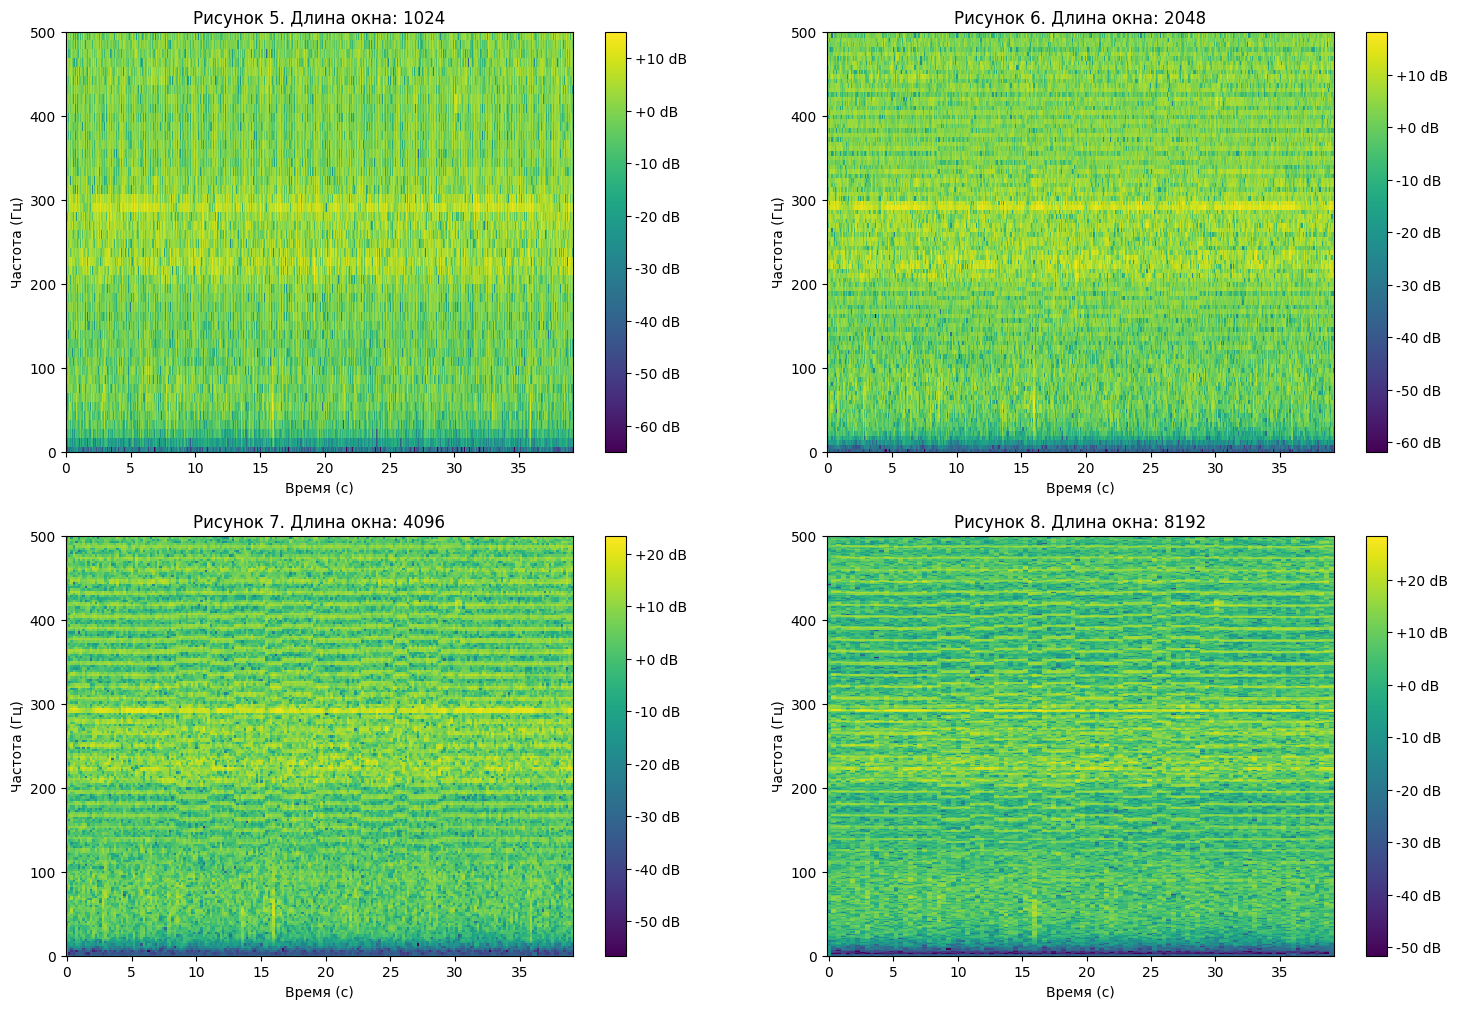

In [ ]:
# Строим спектрограммы сигнала 11_xx_hz с разными длинами окна (в диапазоне (0 - 500) Гц)
fft_size = [1024, 2048, 4096, 8192]

plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    X = librosa.stft(data_11_xx_hz, n_fft=fft_size[i], hop_length=fft_size[i] // 2)
    Xdb = librosa.amplitude_to_db(abs(X))

    img = librosa.display.specshow(
        Xdb,
        sr=sr_11_xx_hz,
        x_axis="time",
        y_axis="hz",
        cmap="viridis",
        n_fft=fft_size[i],
        hop_length=fft_size[i] // 2,
    )
    plt.ylim(0, 500)
    plt.colorbar(img, format="%+2.f dB")
    plt.xlabel("Время (с)")
    plt.ylabel("Частота (Гц)")
    plt.title("Рисунок {:d}.".format(i + 5) + " Длина окна: {:d}".format(fft_size[i]))


# plt.imshow(Cepstralgram, aspect='auto', origin='lower', extent=[time_axis[0], time_axis[-1], quefrency_vector[0], quefrency_vector[-1]], cmap='viridis')

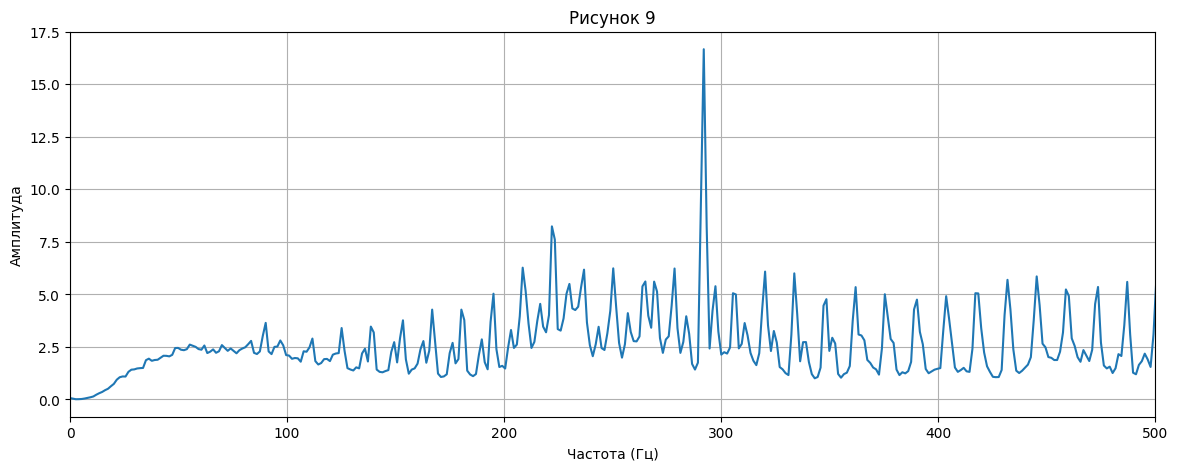

In [ ]:
# Строим и визуализируенм средний амплитудный спектр (в диапазоне (0 - 500) Гц)
n_fft = 8192
f_max = 500
visual_mean_spectrum(data_11_xx_hz, sr_11_xx_hz, n_fft, f_max, "Рисунок 9")

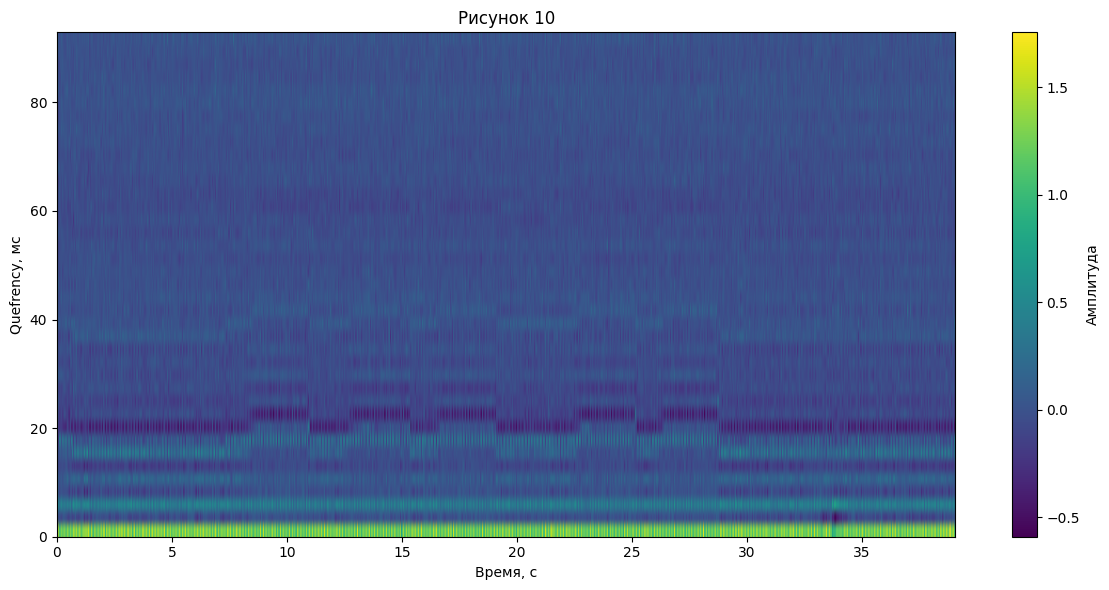

In [ ]:
# Строим и визуализируем кепстрограмму
fft_size = 1024
visual_cepstrogram(data_11_xx_hz, sr_11_xx_hz, fft_size, fft_size // 2, "Рисунок 10")

<div class="alert alert-block alert-success">
<b>Ответ на задание 2:</b>
<a id="answer-job2"></a>

* Постройте средний спектр и попробуйте определить частоту основного тона сигнала.

На спектрограмме горизонтальная линия на частоте 290 Гц.

Самый большой пик у средне амплитудного спектра, $F_0$ где-то примерно 290 Гц также.

* Постройте кепстрограмму и определите частоту основного тона сигнала.

У кепстрограммы полоса где-то на уровне 3-4 мс.
Если взять 3.5, то получим частоту 285 Гц.

* Как период следования импульсов связан с частотой ОТ?

Период следования импульсов обратен частоте ОТ.

</div>

<div class="alert alert-block alert-info">
<b>Задание 3. Тональная структура гласных РС мужчины и женщины</b>
<a id="job3"></a>

* Постройте спектрограмму сигнала **11sp_fm1.wav** и найдите на ней участки ОТ мужчины и женщины.
* Постройте кепстрограмму сигнала и определите интервалы частот ОТ мужчины и женщины
</div>

In [ ]:
# Загружаем сигнал 11sp_fm1.wav (с частотой 11025)
data_11sp_fm1, sr_11sp_fm1 = librosa.load(Speech_dir + "//11sp_fm1.wav", sr=sr11025)

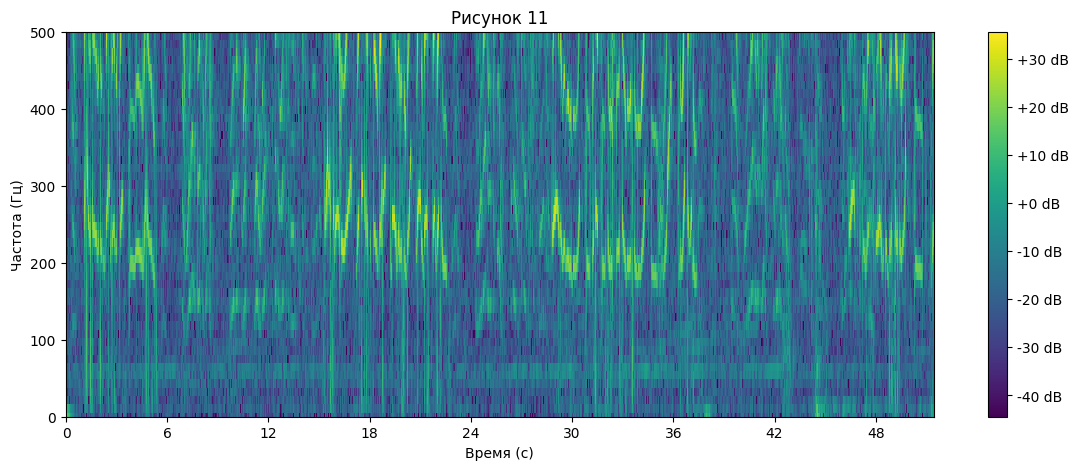

In [ ]:
# Строим спектрограмму сигнала 11sp_fm1  (в диапазоне (0 - 500) Гц)
fft_size = 1024
X = librosa.stft(data_11sp_fm1, n_fft=fft_size, hop_length=fft_size // 2)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(14, 5))
img = librosa.display.specshow(
    Xdb,
    sr=sr_11sp_fm1,
    x_axis="time",
    y_axis="linear",
    cmap="viridis",
    n_fft=fft_size,
    hop_length=fft_size // 2,
)

plt.colorbar(img, format="%+2.f dB")
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.ylim(0, 500)
plt.title("Рисунок 11")
plt.show()

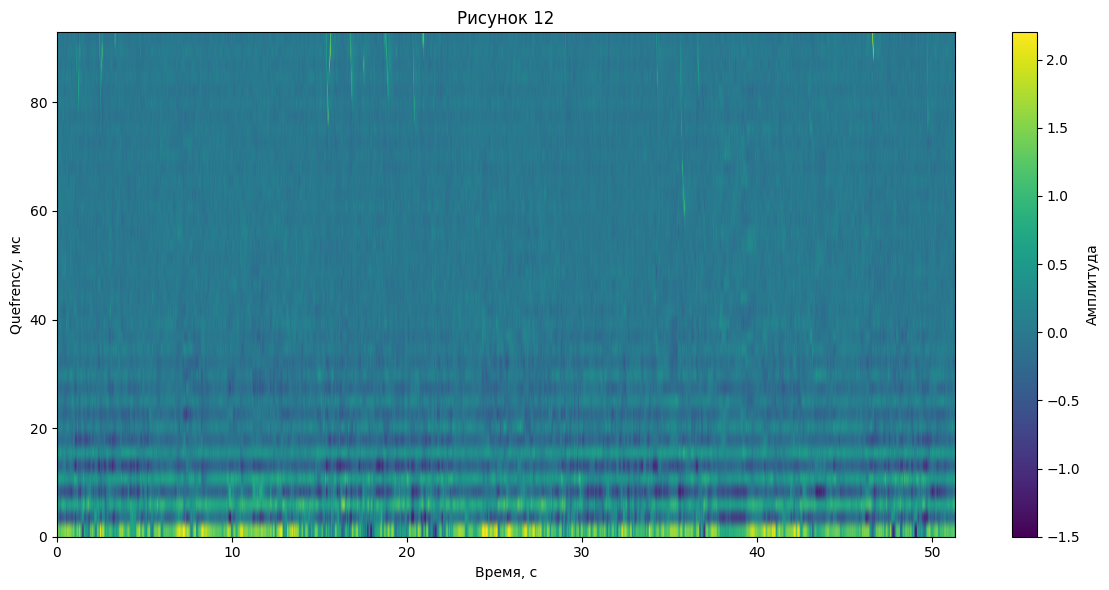

In [ ]:
# Строим и визуализируем кепстрограмму
fft_size = 1024
visual_cepstrogram(data_11sp_fm1, sr_11sp_fm1, fft_size, fft_size // 2, "Рисунок 12")

<div class="alert alert-block alert-success">
<b>Ответ на задание 3:</b>
<a id="answer-job3"></a>

* Постройте спектрограмму сигнала **11sp_fm1.wav** и найдите на ней участки ОТ мужчины и женщины.

Мужской голос имеет более яркие гребни, то есть 0-6, 15-23 итд, а женский более блёклые в промежутках между мужскими

* Постройте кепстрограмму сигнала и определите интервалы частот ОТ мужчины и женщины

На кепстрограмме это выражается в пиках по оси `y` у мужского голоса.
Однако на кепстрограмме эти пики по времени аудио охватывают меньшие по продолжительности участки в сравнение со спектрограммой.

</div>

<div class="alert alert-block alert-info">
<b>Задание 4.</b>
<a id="job4"></a>

* Возьмите речевой сигнал **00704bul.wav**. Постройте кепстрограмму сигнала и определите интервалы частот ОТ.

* Определите частоту ОТ речевого сигнала и оцените скорость её изменения.
</div>

In [ ]:
# Загружаем сигнал 00704bul.wav (с частотой 11025)
data_00704bul, sr_00704bul = librosa.load(Speech_dir + "//00704_bul.wav", sr=sr11025)

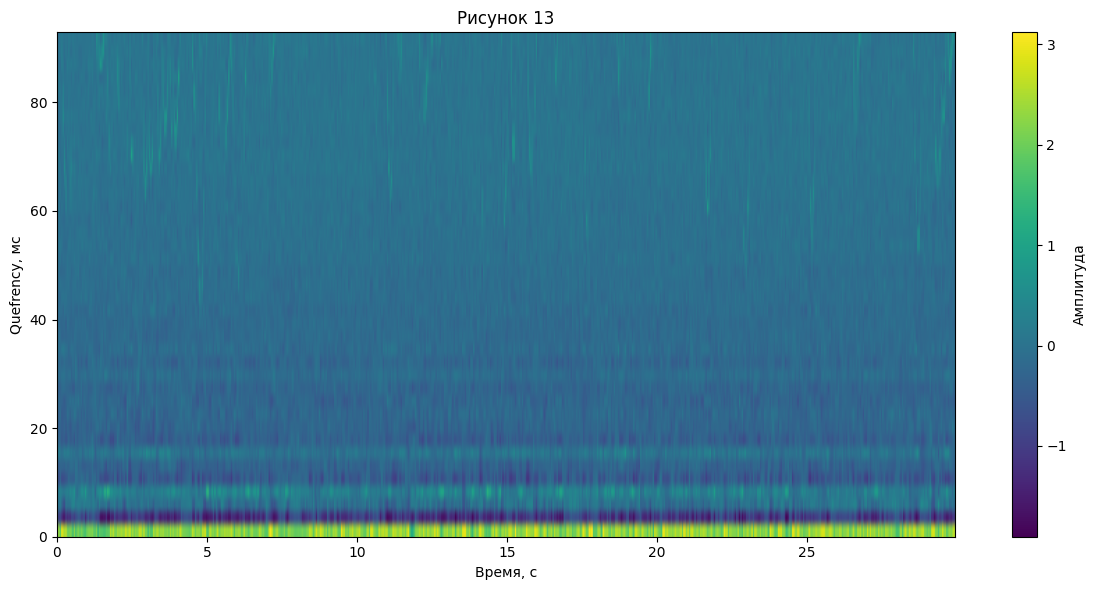

In [ ]:
# Строим и визуализируем кепстрограмму
fft_size = 1024
visual_cepstrogram(data_00704bul, sr_00704bul, fft_size, fft_size // 2, "Рисунок 13")

<div class="alert alert-block alert-success">
<b>Ответ на задание 4:</b>
<a id="answer-job4"></a>

* Возьмите речевой сигнал **00704bul.wav**. Постройте кепстрограмму сигнала и определите интервалы частот ОТ.

Диапозон квефреции примерно до 5 мс. 
Низ возьмём примерно 2.
Делим 1 на эти значения (с учётом перевода мс в с) получаем 200 - 500 Гц.

* Определите частоту ОТ речевого сигнала и оцените скорость её изменения.

Примерно за 0.75 секунд сигнала видим изменение между 5 и 4 мс.
Конвертируем квефреции в частоту, получаем (250 - 200) / 0.75 = 66 Гц/с

</div>

<div class="alert alert-block alert-info">
<b>Задание 5. Исследование тональной структуры и определение частоты ОТ сигналов</b> 
<a id="job5"></a>

* Исследуйте тональную структуру и определите частоту ОТ сигнала писка комара (**komar.wav**)
   
* Исследуйте тональную структуру и определите частоту ОТ сигнала жужжания шмеля (**shmel.wav**)
</div>

In [ ]:
# Загружаем сигнал "писка комара" (с частотой 11025)
data_komar, sr_komar = librosa.load(Speech_dir + "//komar.wav", sr=sr11025)

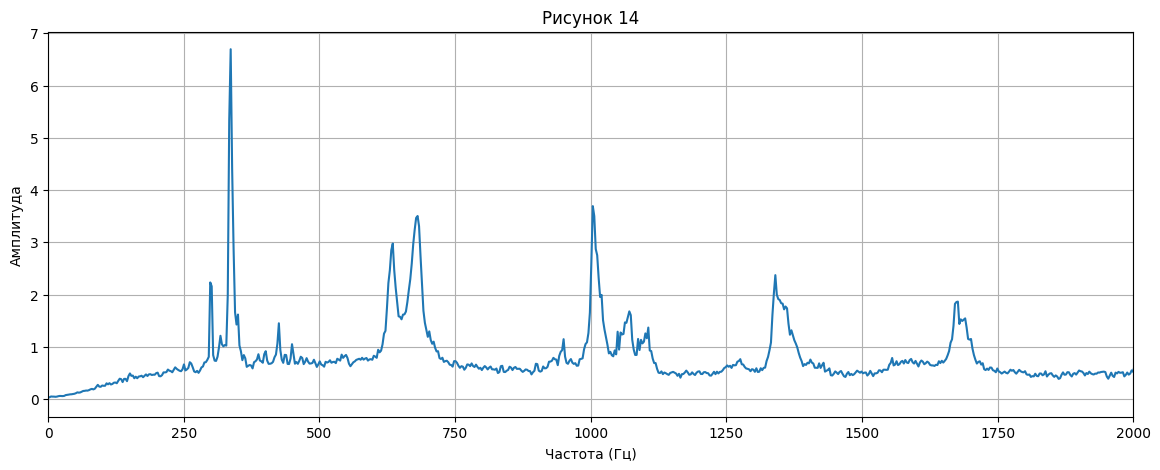

In [ ]:
# Строим и визуализируем средний амплитудный спектр
n_fft = 4096
f_max = 2000
visual_mean_spectrum(data_komar, sr_komar, n_fft, f_max, "Рисунок 14")

In [ ]:
# Загружаем сигнал "жужжания шмеля" (с частотой 11025)
data_shmel, sr_shmel = librosa.load(Speech_dir + "//shmel.wav", sr=sr11025)

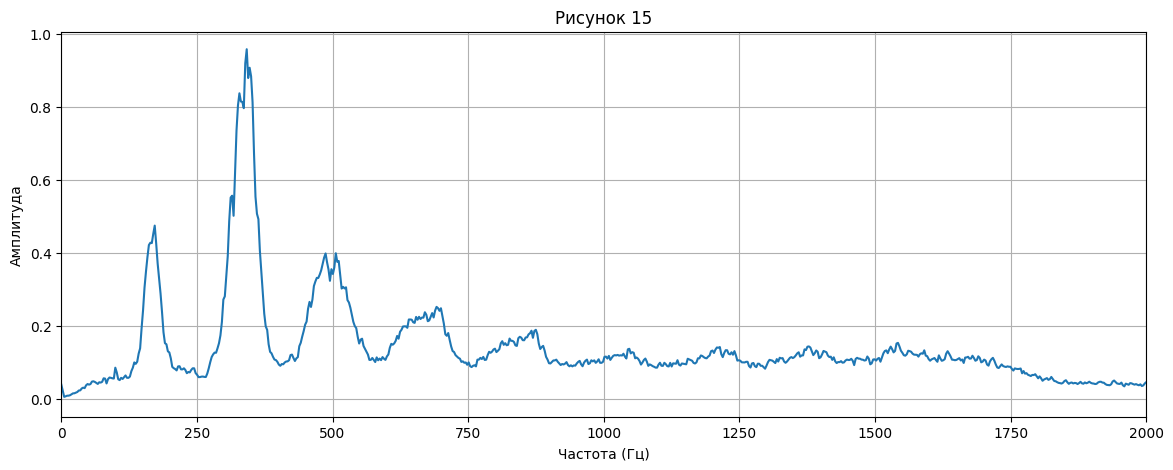

In [ ]:
# Строим и визуализируем средний амплитудный спектр
n_fft = 4096
f_max = 2000
visual_mean_spectrum(data_shmel, sr_shmel, n_fft, f_max, "Рисунок 15")

<div class="alert alert-block alert-success">
<b>Ответ на задание 5:</b>
<a id="answer-job5"></a>

* Исследуйте тональную структуру и определите частоту ОТ сигнала писка комара (**komar.wav**)


У комара сигнал тональный с более узкими пиками.
ОТ находится в районе первого большого пика примерно на 340 Гц, что подтверждается следующими гармониками в районе 670-680 итд.

* Исследуйте тональную структуру и определите частоту ОТ сигнала жужжания шмеля (**shmel.wav**)

У шмеля пики более широкие. Частота ОТ примерно 160-180 Гц. Гармоники менее выражены на частотах > 1000 Гц

</div>

<div class="alert alert-block alert-info">
<b>Задание 6. Исследование периодической структуры сигнала</b> 
<a id="job6"></a>

* Определите период модуляции шума и частоту ОТ в сигнале: по огибающей мощности, спектрограмме, среднему спектру и кепстрограмме.
</div>

In [ ]:
# Загружаем сигнал "16Landa_2012.wav"
data_16Landa_2012, sr_16Landa_2012 = librosa.load(Speech_dir + "//16Landa_2012.wav")

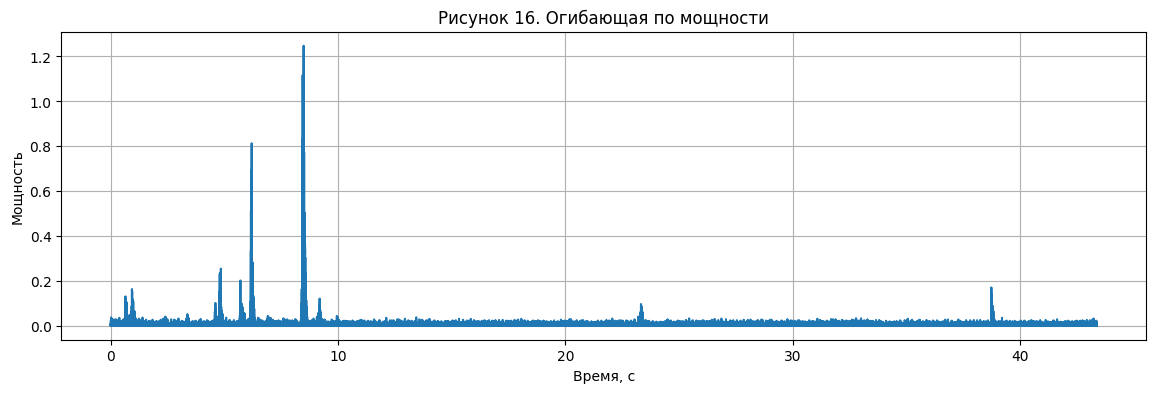

In [ ]:
# Расчёт огибающей (преобразование Гильберта)
analytic_signal = hilbert(data_16Landa_2012)
envelope = np.abs(analytic_signal)
power_envelope = envelope**2

# Время
samples = np.arange(len(power_envelope))
time = samples / sr_16Landa_2012

# Визуализация
plt.figure(figsize=(14, 4))
plt.plot(time, power_envelope)
plt.xlabel("Время, с")
plt.ylabel("Мощность")
plt.title("Рисунок 16. Огибающая по мощности")
plt.grid(True)
plt.show()

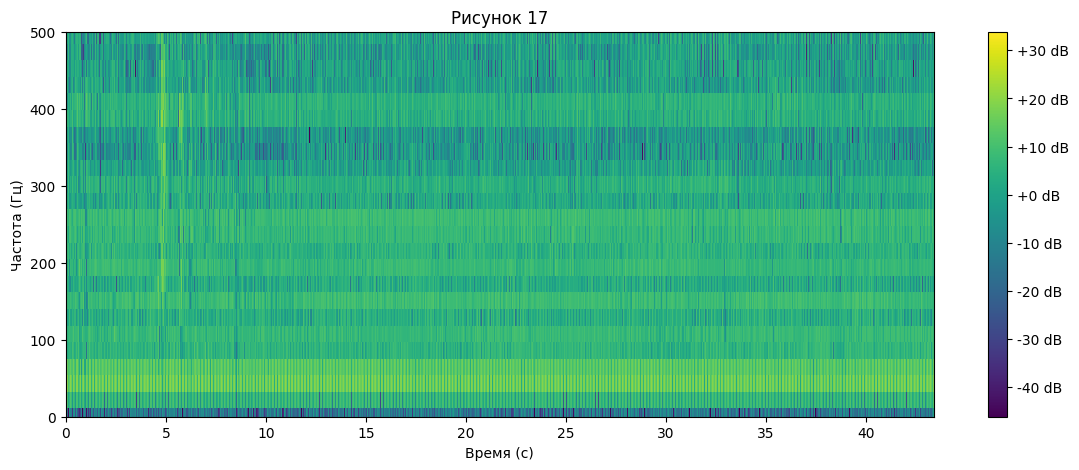

In [ ]:
# Строим спектрограмму сигнала 16Landa_2012.wav (в диапазоне (0 - 500) Гц)
fft_size = 1024
X = librosa.stft(data_16Landa_2012, n_fft=fft_size, hop_length=fft_size // 2)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(14, 5))
img = librosa.display.specshow(
    Xdb,
    sr=sr_16Landa_2012,
    x_axis="time",
    y_axis="linear",
    cmap="viridis",
    n_fft=fft_size,
    hop_length=fft_size // 2,
)

plt.colorbar(img, format="%+2.f dB")
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.ylim(0, 500)
plt.title("Рисунок 17")
plt.show()

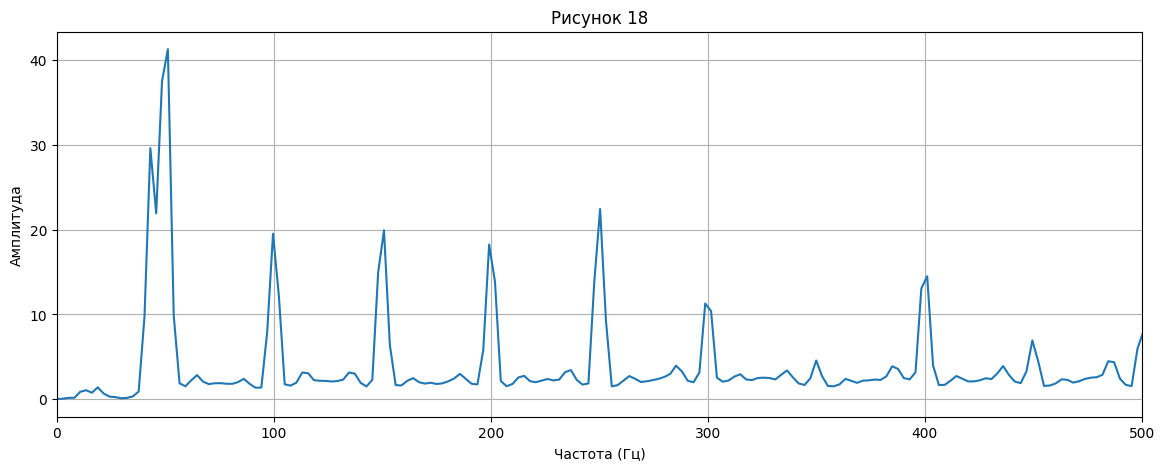

In [ ]:
# Строим и визуализируем средний амплитудный спектр
n_fft = 8192
f_max = 500
visual_mean_spectrum(data_16Landa_2012, sr_16Landa_2012, n_fft, f_max, "Рисунок 18")

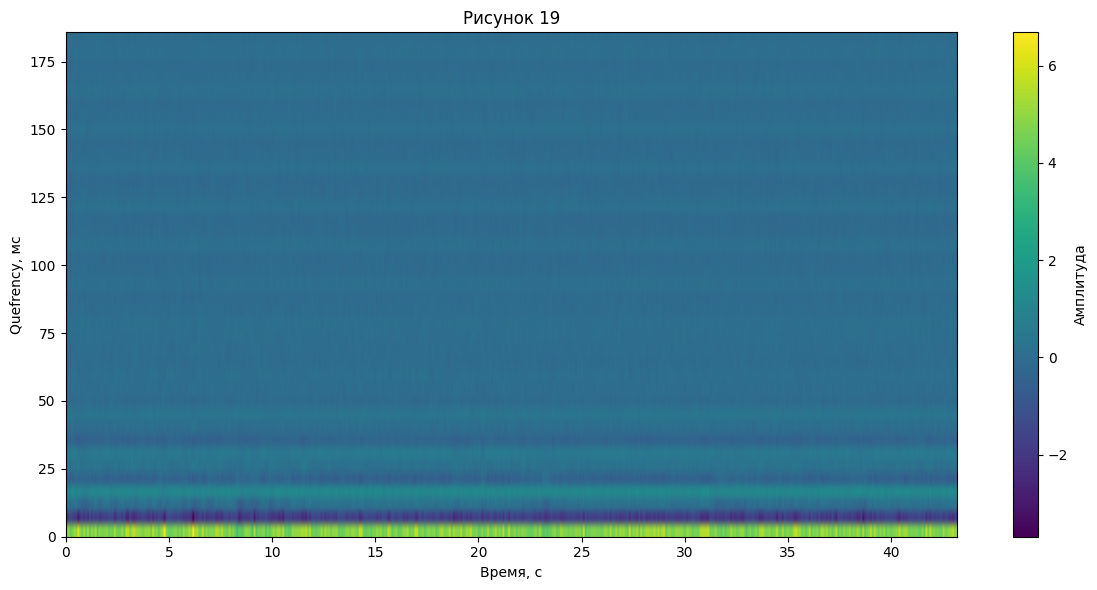

In [ ]:
# Строим и визуализируем кепстрограмму
fft_size = 4096
visual_cepstrogram(
    data_16Landa_2012, sr_16Landa_2012, fft_size, fft_size // 2, "Рисунок 19"
)

<div class="alert alert-block alert-success">
<b>Ответ на задание 6:</b>
<a id="answer-job6"></a>

По огибающей по мощности видно, что на промежутке 0-10 с пики появляются примерно раз в 1-2 с

На спектрограмме видна выраженная горизонтальная полоса на частоте около 50 Гц.

На среднем амплитудном спектре видим пики на 50, 100, 150 Гц. Частота ОТ - 50 Гц.

На кепстрограмме видно яркую полосу в районе 20 мс, что также даёт 50 Гц
</div>